In [1]:
# 24.08.2026, wieczor - test Kroku 1 z niezaleznej recenzji Claude Opus 5
# (xhigh) po spotkaniu z Homola (zrodlo: zrodla/tydzien_0819-0824.txt).
#
# HIPOTEZA DO SPRAWDZENIA (Opus, zastrzega: to hipoteza, nie wynik):
# Wszystkie nasze skany (19-24.08) indeksuja wynik POCZATKIEM okna (t0).
# Artykul w sekcji 4 (analiza cykl-do-cyklu na danych Moskwy, P=3350,
# ~9 lat) podaje 5 minimow PPDF z konkretnymi datami t0 i wartosciami.
# Opus podejrzewa, ze nasz "ukosny pas" (P_days vs pozycja optymalnego t0)
# to sygnatura STALEJ daty kalendarzowej widzianej przez rosnace okno, a po
# odpowiednim przeliczeniu nasz wynik = niezalezna replikacja sekcji 4
# artykulu na 22 stacjach. To tez potencjalnie tlumaczy pytanie Homoli ze
# spotkania: nasze optymalne t0~2009 + P/2 (~4.6 roku) ~= 2013.6, blisko
# dat naglowkowych z artykulu (14 lis 2013 Moskwa, 4 sty 2014 Oulu).
#
# PLAN (caly zero-koszytowy poza Krokiem 3, ktory jest kilkoma pojedynczymi
# ewaluacjami, nie skanem):
# 1. Skleic juz policzone pliki results/cycle_scan_mosc_*_P3350_d5.csv
#    (5 plikow, wszystkie cykle) w jedna ciagla krzywa PPDF-vs-t0 dla
#    Moskwy, 1965-2019, dt=0 (nasza dotychczasowa konwencja).
# 2. Znalezc na tej krzywej lokalne minima PPDF (analogicznie do metody
#    artykulu w sekcji 4) i porownac ich DATY z 5 datami z artykulu -
#    bezposredni test "czy w ogole widzimy minima w podobnych miejscach
#    kalendarza", bez zadnej algebry przesuniec.
# 3. Osobno (tanio, pojedyncze wywolania, NIE skan): ocenic
#    cosmoseismic_stat DOKLADNIE w 5 datach z artykulu, z ICH parametrami
#    (Δt=15 dni - sekcja 4 explicite zachowuje parametry z Fig. 2, ktora
#    uzywa Δt=15d, NIE Δt=0 jak nasza dotychczasowa konwencja z instrukcji
#    Homoli "no lag") - i osobno z dt=0 dla porownania, zeby odizolowac
#    wplyw samego laga od kwestii start-vs-srodek okna.
# 4. Wykres: nasza ciagla krzywa + oznaczone nasze minima + oznaczone
#    minima z artykulu - bezposrednie porownanie wzrokowe.
#
# Wszystko na juz zapisanych plikach (krok 1-2, 4) lub pojedynczych tanich
# wywolaniach (krok 3) - zgodnie z szacunkiem Opusa "~1h, zero nowych
# obliczen".
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import binom, norm

RESULTS_DIR = "../results"
MOSC_PATH = "../data/mosc_data.csv"
USGS_EXTENDED_PATH = "../data/usgs_data/usgs_m4_1965_2025.csv"


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_earthquakes_extended(min_mag=4.0):
    df = pd.read_csv(USGS_EXTENDED_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


# Pieciu minimow z Sekcji 4 artykulu (P. Homola i in. 2023), P=3350d
# (~9 lat), d=5d, m=4.0 - "z tymi samymi wartosciami co Fig. 2" czyli
# Δt=15d (NIE Δt=0 - to jest odstepstwo od naszej dotychczasowej
# konwencji "no lag" z instrukcji Homoli, tu explicite testowane osobno).
ARTICLE_P_DAYS = 3350
ARTICLE_D_DAYS = 5
ARTICLE_M = 4.0
ARTICLE_DT_DAYS = 15

article_minima = pd.DataFrame([
    dict(t0=pd.Timestamp("1969-07-12 07:37:12"), PPDF=3.3e-8),
    dict(t0=pd.Timestamp("1978-07-11 07:37:12"), PPDF=3.0e-6),
    dict(t0=pd.Timestamp("1988-09-21 07:37:12"), PPDF=3.6e-5),
    dict(t0=pd.Timestamp("1999-12-23 07:37:12"), PPDF=2.9e-6),
    dict(t0=pd.Timestamp("2009-02-23 07:37:12"), PPDF=8.1e-9),
])
print(article_minima.to_string(index=False))

                 t0         PPDF
1969-07-12 07:37:12 3.300000e-08
1978-07-11 07:37:12 3.000000e-06
1988-09-21 07:37:12 3.600000e-05
1999-12-23 07:37:12 2.900000e-06
2009-02-23 07:37:12 8.100000e-09


In [2]:
# KROK 1: sklejenie juz policzonych plikow cycle_scan_mosc_*_P3350_d5.csv
# (5 plikow, wszystkie cykle 1964-2008, dt=0) w jedna ciagla krzywa
# PPDF-vs-t0 na osi kalendarzowej - zero nowych obliczen.
frames = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_mosc_cycle_*_P3350_d5.csv"))):
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    frames.append(df)
    print(f"{os.path.basename(path)}: {len(df)} wierszy, {df['t0'].min()} .. {df['t0'].max()}")

mosc_curve = pd.concat(frames, ignore_index=True).sort_values("t0").reset_index(drop=True)
print(f"\nLaczna krzywa (dt=0): {len(mosc_curve)} punktow, {mosc_curve['t0'].min()} .. {mosc_curve['t0'].max()}")

cycle_scan_mosc_cycle_1964_P3350_d5.csv: 4048 wierszy, 1965-01-02 00:00:00 .. 1976-02-01 00:00:00
cycle_scan_mosc_cycle_1976_P3350_d5.csv: 3743 wierszy, 1976-02-01 00:00:00 .. 1986-05-01 00:00:00
cycle_scan_mosc_cycle_1986_P3350_d5.csv: 3685 wierszy, 1986-05-01 00:00:00 .. 1996-06-01 00:00:00
cycle_scan_mosc_cycle_1996_P3350_d5.csv: 4537 wierszy, 1996-06-01 00:00:00 .. 2008-11-01 00:00:00
cycle_scan_mosc_cycle_2008_P3350_d5.csv: 2586 wierszy, 2008-11-01 00:00:00 .. 2015-11-30 00:00:00

Laczna krzywa (dt=0): 18599 punktow, 1965-01-02 00:00:00 .. 2015-11-30 00:00:00


In [3]:
# KROK 2: lokalne minima PPDF na naszej krzywej (analogicznie do metody
# artykulu w sekcji 4 - "distinct minima"), min. odstep 8 lat (ponizej
# najkrotszej odleglosci miedzy minimami artykulu, ~9-11 lat) zeby nie
# lapac szumu. Dopasowanie do 5 dat z artykulu po NAJBLIZSZYM Z NASZYCH
# ZNALEZIONYCH MINIMOW (nie po najblizszym punkcie siatki - to dawaloby
# trywialny offset ~0, bo kandydaci sa co 24h) - bezposredni test
# kalendarzowy, bez zadnej algebry przesuniec.
with np.errstate(divide="ignore"):
    neglog_ppdf = -np.log10(np.clip(mosc_curve["PPDF"].to_numpy(dtype=float), 1e-300, None))

MIN_SEPARATION_DAYS = 8 * 365  # ok. 8 lat, krok siatki = 1 dzien (24h)
peak_idx, _ = find_peaks(neglog_ppdf, distance=MIN_SEPARATION_DAYS)
our_minima = mosc_curve.iloc[peak_idx][["t0", "PPDF"]].copy()
our_minima["neglog10_PPDF"] = -np.log10(our_minima["PPDF"].clip(lower=1e-300))
our_minima = our_minima.sort_values("neglog10_PPDF", ascending=False).reset_index(drop=True)
print(f"Znaleziono {len(our_minima)} lokalnych minimow PPDF (odstep >= 8 lat):")
print(our_minima.to_string(index=False))

# Dopasowanie kazdego minimum z artykulu do najblizszego NASZEGO ZNALEZIONEGO
# MINIMUM (z tabeli our_minima powyzej, nie do dowolnego punktu siatki).
matches = []
for _, row in article_minima.iterrows():
    diffs = (our_minima["t0"] - row["t0"]).abs()
    nearest_i = diffs.idxmin()
    our_t0 = our_minima.loc[nearest_i, "t0"]
    our_ppdf = our_minima.loc[nearest_i, "PPDF"]
    offset_days = (our_t0 - row["t0"]).days
    matches.append(dict(
        article_t0=row["t0"], article_PPDF=row["PPDF"],
        our_nearest_minimum_t0=our_t0, our_PPDF_at_that_minimum=our_ppdf,
        offset_days=offset_days,
        offset_as_fraction_of_P=offset_days / ARTICLE_P_DAYS,
    ))
match_table = pd.DataFrame(matches)
print("\nDopasowanie do dat z artykulu (offset_days = data_naszego_minimum - data_artykulu;"
      " oczekiwanie pod hipoteza Opusa: offset bliski -P/2 = -1675d):")
print(match_table.to_string(index=False))
match_table.to_csv(f"{RESULTS_DIR}/article_section4_calendar_match.csv", index=False)

Znaleziono 5 lokalnych minimow PPDF (odstep >= 8 lat):
        t0         PPDF  neglog10_PPDF
1968-04-24 3.958290e-08       7.402492
1978-03-10 1.111942e-07       6.953918
1988-04-22 8.570888e-07       6.066974
2000-03-30 2.027063e-06       5.693133
2008-04-06 1.448502e-05       4.839081

Dopasowanie do dat z artykulu (offset_days = data_naszego_minimum - data_artykulu; oczekiwanie pod hipoteza Opusa: offset bliski -P/2 = -1675d):
         article_t0  article_PPDF our_nearest_minimum_t0  our_PPDF_at_that_minimum  offset_days  offset_as_fraction_of_P
1969-07-12 07:37:12  3.300000e-08             1968-04-24              3.958290e-08         -445                -0.132836
1978-07-11 07:37:12  3.000000e-06             1978-03-10              1.111942e-07         -124                -0.037015
1988-09-21 07:37:12  3.600000e-05             1988-04-22              8.570888e-07         -153                -0.045672
1999-12-23 07:37:12  2.900000e-06             2000-03-30              2.027063e-0

In [4]:
# KROK 3: bezposrednia ewaluacja cosmoseismic_stat DOKLADNIE w 5 datach z
# artykulu (do sekundy) - dwa warianty laga: Δt=15d (dokladny przepis
# sekcji 4/Fig.2) i Δt=0 (nasza dotychczasowa konwencja "no lag" z
# instrukcji Homoli) - zeby odizolowac wplyw samego laga. To NIE jest skan
# (10 pojedynczych wywolan cosmoseismic_stat), wiec tanie mimo swiezego
# wczytania danych.
mosc_full = load_mosc()
eq_extended = load_earthquakes_extended(min_mag=ARTICLE_M)
print(f"mosc: {len(mosc_full)} pomiarow, {mosc_full.index.min()} .. {mosc_full.index.max()}")
print(f"EQ (rozszerzony katalog, M>={ARTICLE_M}): {len(eq_extended)} zdarzen, "
      f"{eq_extended.index.min()} .. {eq_extended.index.max()}")

point_rows = []
for _, row in article_minima.iterrows():
    for dt_days, label in [(ARTICLE_DT_DAYS, "dt=15 (przepis artykulu)"), (0, "dt=0 (nasza konwencja)")]:
        r = cosmoseismic_stat(mosc_full, eq_extended, row["t0"], ARTICLE_P_DAYS, ARTICLE_D_DAYS, ARTICLE_M, dt_days)
        point_rows.append(dict(
            article_t0=row["t0"], article_PPDF=row["PPDF"], wariant=label,
            nasz_PPDF=r["PPDF"], Np=r["Np"], Nm=r["Nm"], N_valid=r["N_valid"],
            log10_roznica=(np.log10(r["PPDF"]) - np.log10(row["PPDF"])) if r["PPDF"] and r["PPDF"] > 0 else np.nan,
        ))

point_eval = pd.DataFrame(point_rows)
pd.set_option("display.width", 160)
print(point_eval.to_string(index=False))
point_eval.to_csv(f"{RESULTS_DIR}/article_section4_point_eval.csv", index=False)

mosc: 91824 pomiarow, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
EQ (rozszerzony katalog, M>=4.0): 507919 zdarzen, 1965-01-01 08:04:17.780000 .. 2025-01-31 23:57:39.481000
         article_t0  article_PPDF                  wariant  nasz_PPDF  Np  Nm  N_valid  log10_roznica
1969-07-12 07:37:12  3.300000e-08 dt=15 (przepis artykulu)   0.006776 311 356      667       5.312434
1969-07-12 07:37:12  3.300000e-08   dt=0 (nasza konwencja)   0.000870 299 368      667       4.420776
1978-07-11 07:37:12  3.000000e-06 dt=15 (przepis artykulu)   0.000022 284 382      666       0.874914
1978-07-11 07:37:12  3.000000e-06   dt=0 (nasza konwencja)   0.000252 293 373      666       1.924324
1988-09-21 07:37:12  3.600000e-05 dt=15 (przepis artykulu)   0.000062 288 379      667       0.233115
1988-09-21 07:37:12  3.600000e-05   dt=0 (nasza konwencja)   0.000014 283 384      667      -0.395384
1999-12-23 07:37:12  2.900000e-06 dt=15 (przepis artykulu)   0.000034 285 380      665       1.075336
1999-12-23 0

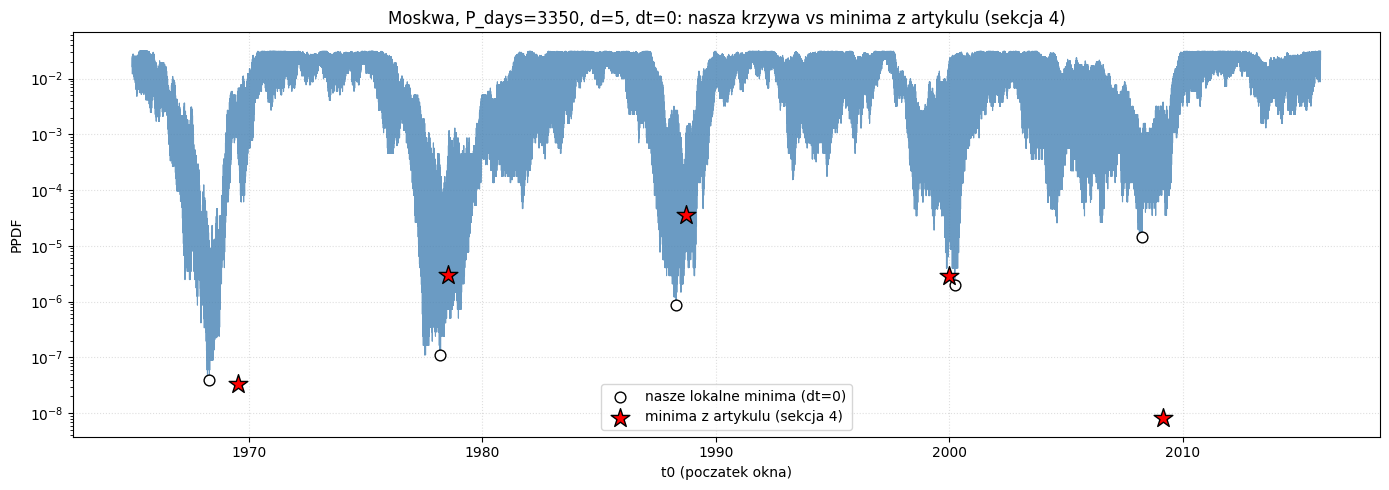

In [5]:
# KROK 4: wykres - nasza ciagla krzywa PPDF-vs-t0 (Moskwa, P=3350, d=5,
# dt=0, 1965-2019) w skali logarytmicznej (jak Fig. 2/4 artykulu), z
# oznaczonymi NASZYMI lokalnymi minimami (biale kolka) i minimami Z
# ARTYKULU (czerwone gwiazdki) - bezposrednie porownanie wzrokowe pozycji
# w kalendarzu.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mosc_curve["t0"], mosc_curve["PPDF"], color="steelblue", lw=0.8, alpha=0.8)
ax.scatter(our_minima["t0"], our_minima["PPDF"], color="white", edgecolor="black",
           s=60, zorder=5, label="nasze lokalne minima (dt=0)")
ax.scatter(article_minima["t0"], article_minima["PPDF"], color="red", marker="*",
           s=200, edgecolor="black", zorder=6, label="minima z artykulu (sekcja 4)")
ax.set_yscale("log")
ax.set_xlabel("t0 (poczatek okna)")
ax.set_ylabel("PPDF")
ax.set_title("Moskwa, P_days=3350, d=5, dt=0: nasza krzywa vs minima z artykulu (sekcja 4)")
ax.legend()
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/article_section4_comparison_plot.png", dpi=120)
plt.show()